In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

1. Выбрать подходящую таблицу данных. Построить и визуализировать дерево решений.


In [2]:
df = pd.read_csv('../Data/mmda5/fish_data.csv')
print(df)

                    species  length  weight  w_l_ratio
0        Anabas testudineus   10.66    3.45       0.32
1        Anabas testudineus    6.91    3.27       0.47
2        Anabas testudineus    8.38    3.46       0.41
3        Anabas testudineus    7.57    3.36       0.44
4        Anabas testudineus   10.83    3.38       0.31
...                     ...     ...     ...        ...
4075  Sillaginopsis panijus   30.56    6.12       0.20
4076  Sillaginopsis panijus   29.66    6.11       0.21
4077  Sillaginopsis panijus   32.81    6.25       0.19
4078  Sillaginopsis panijus   29.78    6.11       0.21
4079  Sillaginopsis panijus   31.62    6.14       0.19

[4080 rows x 4 columns]


In [3]:
label_encoder = LabelEncoder()
df['species'] = label_encoder.fit_transform(df['species'])


In [4]:
X = df.drop(columns=['species'])
y = df['species']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

accuracy: 0.9387254901960784


[Text(0.4620411408253205, 0.9827586206896551, 'x[1] <= 4.41\ngini = 0.889\nsamples = 3264\nvalue = [381, 332, 374, 348, 380, 367, 334, 384, 364]'),
 Text(0.44537447415865383, 0.9482758620689655, 'x[2] <= 0.245\ngini = 0.857\nsamples = 2520\nvalue = [381.0, 332.0, 374.0, 348.0, 0.0, 367.0, 334.0, 384.0\n0.0]'),
 Text(0.45370780749198714, 0.9655172413793103, 'True  '),
 Text(0.4274257562099359, 0.9137931034482759, 'x[1] <= 3.45\ngini = 0.801\nsamples = 1770\nvalue = [0, 332, 374, 348, 0, 8, 324, 384, 0]'),
 Text(0.4171693459535256, 0.8793103448275862, 'x[0] <= 22.11\ngini = 0.749\nsamples = 1412\nvalue = [0.0, 330.0, 374.0, 0.0, 0.0, 0.0, 324.0, 384.0, 0.0]'),
 Text(0.4120411408253205, 0.8448275862068966, 'x[1] <= 2.77\ngini = 0.665\nsamples = 1082\nvalue = [0, 0, 374, 0, 0, 0, 324, 384, 0]'),
 Text(0.4069129356971154, 0.8103448275862069, 'gini = 0.0\nsamples = 324\nvalue = [0, 0, 0, 0, 0, 0, 324, 0, 0]'),
 Text(0.4171693459535256, 0.8103448275862069, 'x[1] <= 3.105\ngini = 0.5\nsamples 

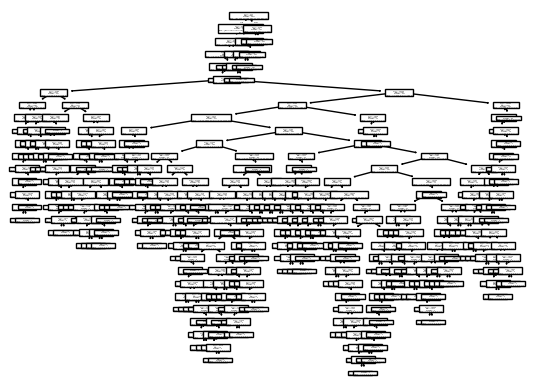

In [6]:
from sklearn.metrics import accuracy_score

clf = tree.DecisionTreeClassifier()
clf = clf.fit(X_train, y_train)
clf.fit(X_train, y_train)
clf_pred_res = clf.predict(X_test)
clf_accuracy = accuracy_score(y_test, clf_pred_res)

print(f'accuracy: {clf_accuracy}')
tree.plot_tree(clf)

2. Применить метод градиентного бустинга. Вычислить значимость переменных. Выдать список построенных деревьев.


In [7]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(n_estimators=10, learning_rate=0.1, max_depth=3, random_state=42, criterion="squared_error")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")


Accuracy: 0.9399509803921569


Variable Importance:
     Feature  Importance
0     length    0.352691
1     weight    0.343952
2  w_l_ratio    0.303357


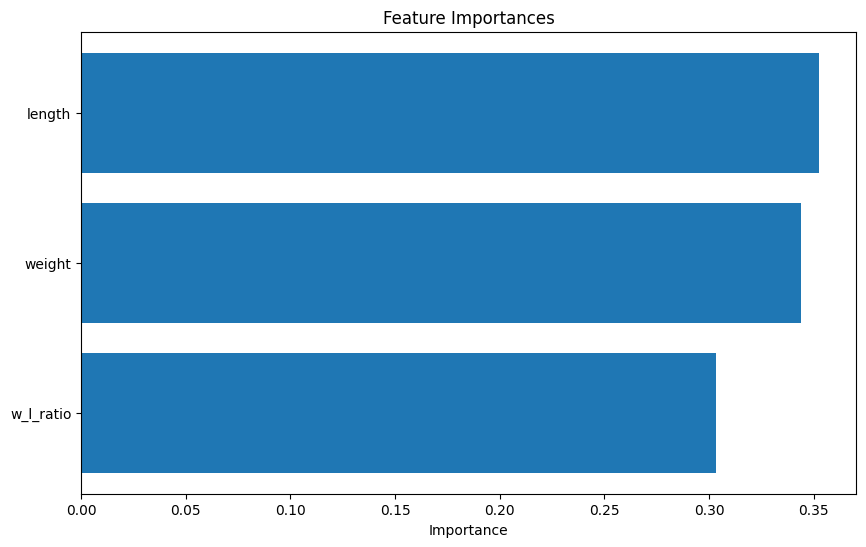

In [8]:
feature_importances = model.feature_importances_

importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Variable Importance:")
print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.show()


Number of trees: 10


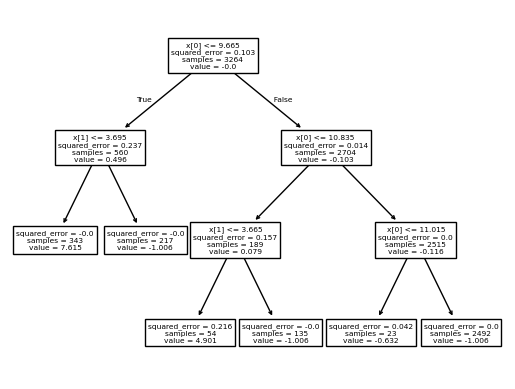

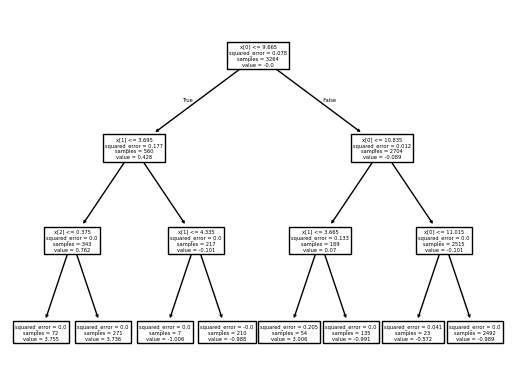

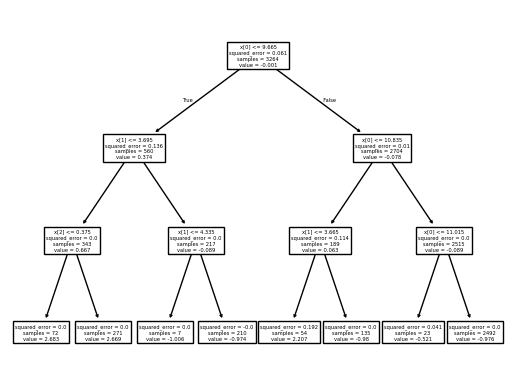

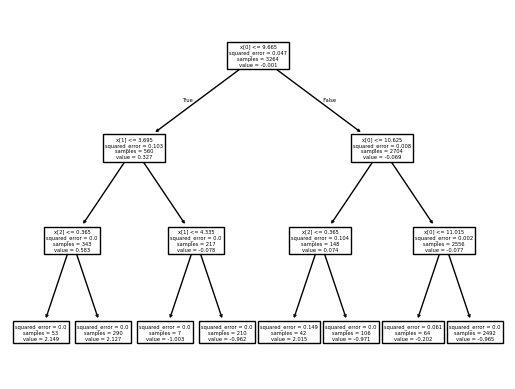

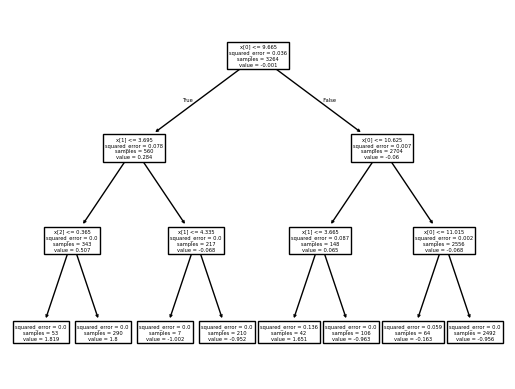

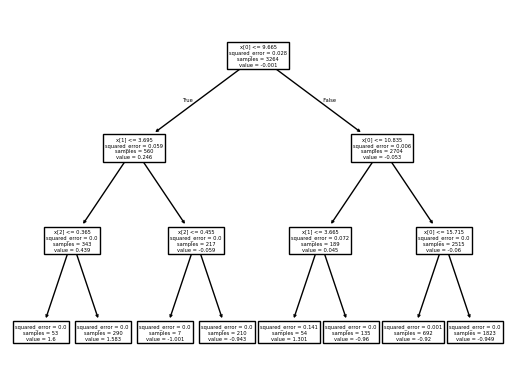

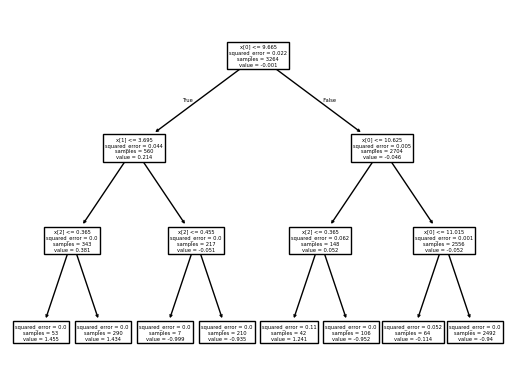

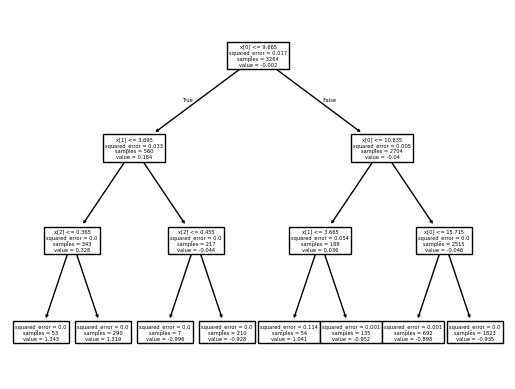

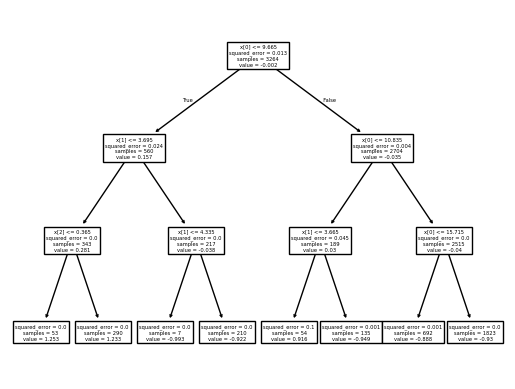

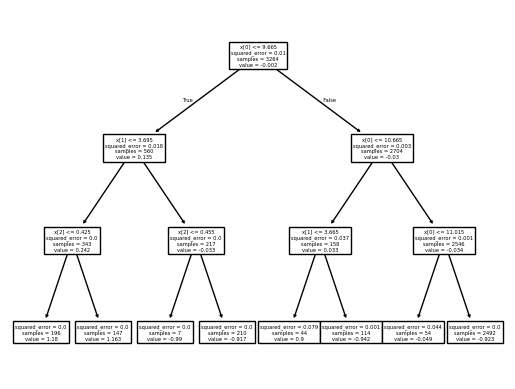

In [9]:
n_estimators = len(model.estimators_)

print(f"Number of trees: {n_estimators}")
for i, tre in enumerate(model.estimators_[:, 0]):
    # print(f"Tree {i+1}:")
    # print(tre)
    tree.plot_tree(tre)
    plt.show()

3. Построить зависимость качества дерева решения (на кросс-валидации) от числа вершин дерева.


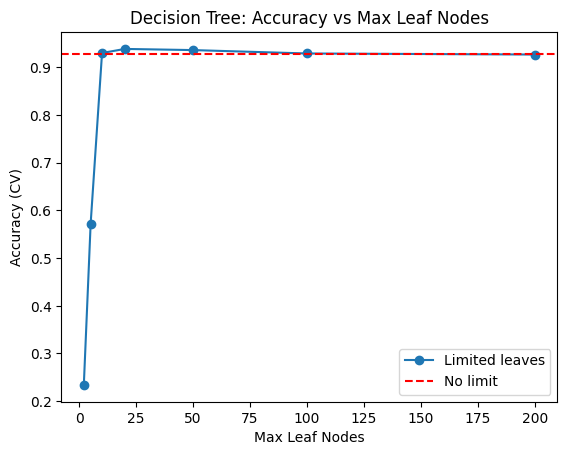

0.9279411764705883


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

max_leaf_nodes = [2, 5, 10, 20, 50, 100, 200, None]
scores = []

for max_leaf in max_leaf_nodes:
    model = DecisionTreeClassifier(max_leaf_nodes=max_leaf, random_state=42)
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    scores.append(cv_scores.mean())

plt.plot(max_leaf_nodes[:-1], scores[:-1], marker='o', label='Limited leaves')
plt.axhline(scores[-1], color='r', linestyle='--', label='No limit')
plt.xlabel('Max Leaf Nodes')
plt.ylabel('Accuracy (CV)')
plt.title('Decision Tree: Accuracy vs Max Leaf Nodes')
plt.legend()
plt.show()
print(scores[-1])

4. Для метода градиентного бустинга построить зависимость качества решения (на кросс-валидации) от числа деревьев.

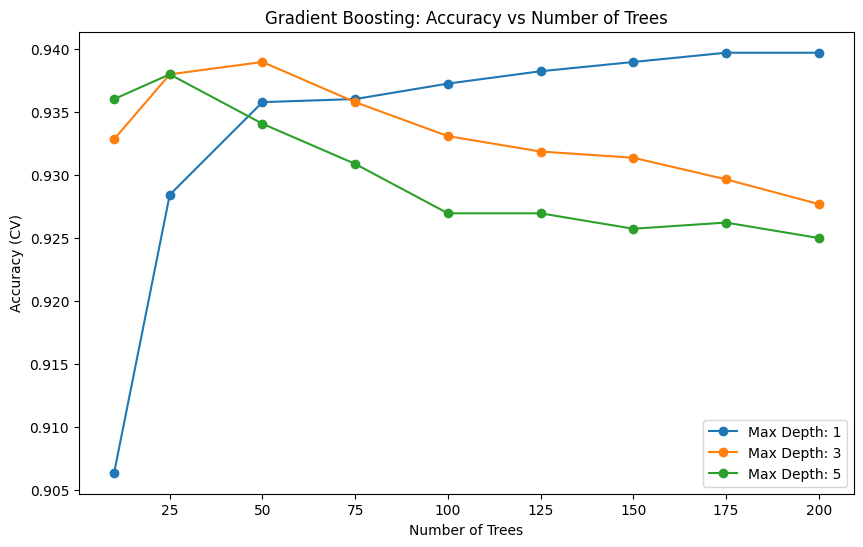

In [11]:
from sklearn.ensemble import GradientBoostingClassifier

n_estimators_list = [10, 25, 50, 75, 100, 125, 150, 175, 200]
max_depth_list = [1, 3, 5]
results = {}

for max_depth in max_depth_list:
    scores = []
    for n_estimators in n_estimators_list:
        model = GradientBoostingClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
        cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
        scores.append(cv_scores.mean())
    results[max_depth] = scores

plt.figure(figsize=(10, 6))
for max_depth, scores in results.items():
    plt.plot(n_estimators_list, scores, marker='o', label=f'Max Depth: {max_depth}')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy (CV)')
plt.title('Gradient Boosting: Accuracy vs Number of Trees')
plt.legend()
plt.show()


5. Выполнить предыдущий пункт для случайного леса.


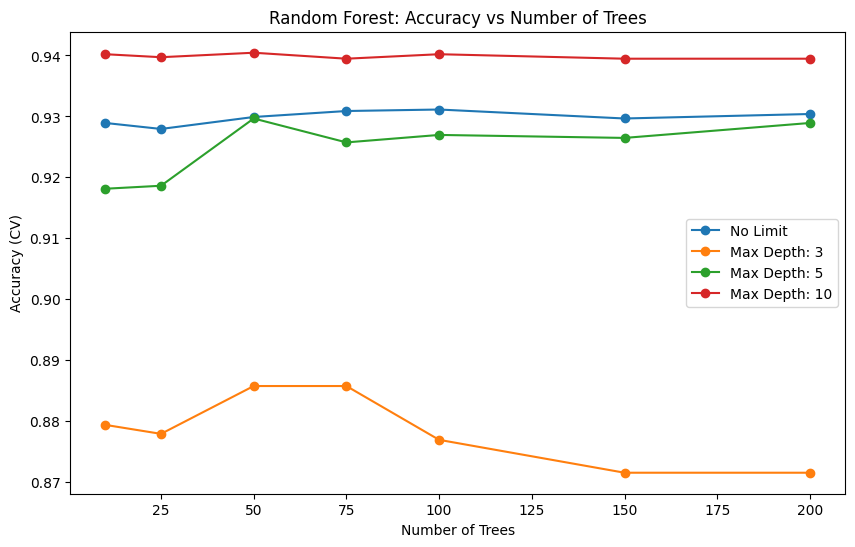

In [12]:
from sklearn.ensemble import RandomForestClassifier

n_estimators_list = [10, 25, 50, 75, 100, 150, 200]
max_depth_list = [None, 3, 5, 10]
results_rf = {}

for max_depth in max_depth_list:
    scores = []
    for n_estimators in n_estimators_list:
        model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
        cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
        scores.append(cv_scores.mean())
    results_rf[max_depth] = scores

plt.figure(figsize=(10, 6))
for max_depth, scores in results_rf.items():
    depth_label = 'No Limit' if max_depth is None else f'Max Depth: {max_depth}'
    plt.plot(n_estimators_list, scores, marker='o', label=depth_label)
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy (CV)')
plt.title('Random Forest: Accuracy vs Number of Trees')
plt.legend()
plt.show()
